In [90]:
import json
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from umap.umap_ import UMAP
import seaborn as sns

In [20]:
with open('../configs/generation_config.yaml', 'r') as file:
    generation_config = yaml.safe_load(file)
        
with open('../psychometric_tests/hexaco_100_eval.yaml', 'r') as file:
    hexaco_eval = yaml.safe_load(file)

In [3]:
def read_json(file_path):
    with open(file_path, "r") as f:
        file = json.load(f)
    return file

In [4]:
data_dir = "hf_personas_hexaco_results_v0"

In [5]:
hf_persona_hexaco_results = {}
for filename in os.listdir(data_dir):
    file_path = os.path.join(data_dir, filename)
    file = read_json(file_path)
    hf_persona_hexaco_results =  hf_persona_hexaco_results | file

In [6]:
len(hf_persona_hexaco_results.keys())

300

In [32]:
persona_hexaco_str_answers_df = pd.DataFrame([{"persona_id": key, "answers": hf_persona_hexaco_results[key]['answers'][0]} for key in hf_persona_hexaco_results.keys()])

persona_hexaco_str_answers_df = pd.DataFrame(persona_hexaco_str_answers_df['answers'].to_list(), columns = list(range(0,100)), index = persona_hexaco_str_answers_df['persona_id'])

In [33]:
mapping = {"Strongly Disagree": -2, "Disagree": -1, "Neutral": 0, "Agree": 1, "Strongly Agree":2}

In [34]:
persona_hexaco_df = persona_hexaco_str_answers_df.replace(mapping)

/var/folders/9b/k67tngbx13jgzw5kjx9_d0tc0000gn/T/ipykernel_13426/4289547850.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  persona_hexaco_df = persona_hexaco_str_answers_df.replace(mapping)


## PCA and Eigen Value Analysis

In [106]:
np.cov(persona_hexaco_df.values.T).shape

(100, 100)

(array([96.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.        , 0.9029047 , 1.8058094 , 2.70871411, 3.61161881,
        4.51452351, 5.41742821, 6.32033291, 7.22323762, 8.12614232,
        9.02904702]),
 <BarContainer object of 10 artists>)

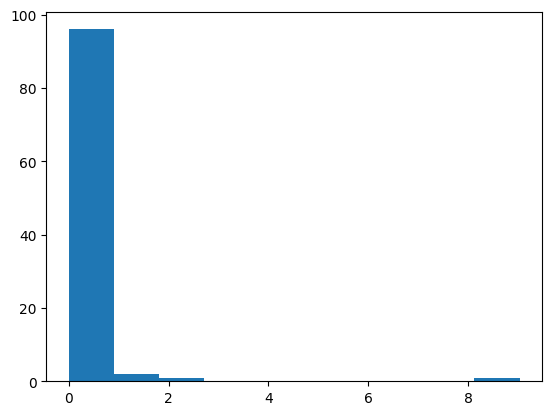

In [103]:
plt.hist(np.linalg.eigvals(np.cov(persona_hexaco_df.values.T)))

## Interfactor Correlation / Clustering

In [ ]:
umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_reduced = umap_model.fit_transform(persona_hexaco_df)

In [15]:
kmeans_model = KMeans(n_clusters=10, random_state=42)
kmeans_model.fit(X_reduced)

,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [16]:
labels = kmeans_model.labels_
centroids = kmeans_model.cluster_centers_

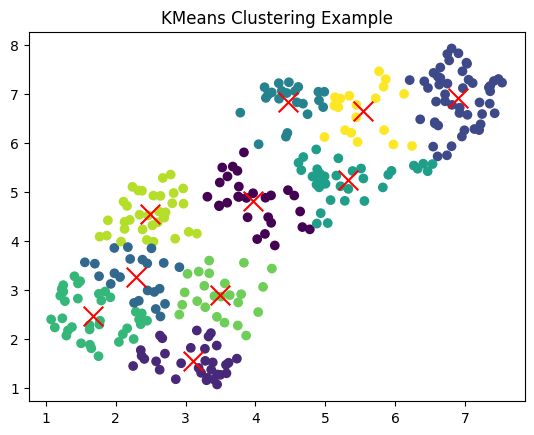

In [17]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', marker='o')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200)
plt.title("KMeans Clustering Example")
plt.show()

In [18]:
labels

array([0, 1, 2, 7, 6, 0, 2, 4, 6, 3, 0, 5, 4, 6, 9, 2, 0, 9, 2, 6, 8, 1,
       5, 8, 9, 8, 6, 8, 8, 5, 1, 7, 1, 2, 2, 4, 1, 8, 0, 6, 7, 0, 9, 3,
       2, 6, 8, 9, 1, 8, 3, 4, 8, 4, 8, 4, 2, 7, 7, 1, 9, 6, 5, 7, 2, 1,
       9, 0, 4, 7, 2, 6, 2, 5, 7, 6, 2, 5, 7, 3, 9, 1, 1, 9, 6, 2, 3, 5,
       8, 2, 8, 5, 3, 4, 6, 5, 4, 8, 2, 6, 1, 8, 3, 3, 2, 1, 4, 7, 7, 2,
       2, 6, 0, 5, 1, 5, 3, 4, 6, 9, 1, 0, 9, 8, 8, 5, 8, 2, 1, 5, 7, 0,
       8, 4, 3, 3, 8, 2, 3, 6, 5, 6, 0, 2, 3, 9, 3, 0, 0, 6, 9, 1, 6, 0,
       7, 1, 2, 8, 9, 2, 3, 0, 7, 6, 5, 6, 5, 0, 6, 9, 8, 4, 7, 1, 1, 5,
       3, 5, 7, 4, 9, 4, 2, 6, 5, 7, 5, 2, 6, 2, 5, 8, 2, 6, 6, 5, 2, 2,
       1, 2, 1, 0, 0, 1, 2, 3, 5, 0, 3, 6, 5, 2, 4, 8, 8, 8, 5, 5, 1, 1,
       8, 7, 2, 6, 9, 0, 0, 2, 2, 6, 5, 4, 2, 3, 2, 6, 5, 0, 7, 2, 3, 0,
       7, 6, 1, 2, 0, 2, 5, 6, 2, 8, 5, 6, 2, 4, 7, 4, 0, 1, 8, 8, 2, 1,
       2, 8, 2, 7, 8, 8, 5, 0, 1, 3, 7, 2, 1, 0, 4, 0, 1, 2, 8, 6, 4, 6,
       5, 9, 1, 9, 6, 2, 3, 5, 5, 1, 8, 2, 4, 7], d

## Inter Correlations

- for every persona, calculate score across six traits - gives 300 x 6 dataframe, and get correlation

In [77]:
def calculate_hexaco_score(trait, subtrait, answers, likert_scale = generation_config['likert_scale']):
    # answer_dict = {}
    answers = [answer if answer in likert_scale else "Do not wish to answer" for answer in answers]
    answers = pd.Series(answers)
    subtrait_dict = hexaco_eval[trait][subtrait]
    indices = [idx - 1 for idx in subtrait_dict['indices']]
    trait_answers = answers[indices]
    refused_answers = trait_answers[trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    non_refused_answers = trait_answers[~trait_answers.isin(['Do not wish to answer','Do not wish to answer.'])]
    answer_indices = [likert_scale.index(answer) + 1 for answer in non_refused_answers]
    # print(answer_indices)
    true_answer_indices = [6-idx if reverse else idx for idx,reverse in zip(answer_indices, subtrait_dict['reverse'])]
    
    # answer_dict['answer_indices'] = answer_indices
    # answer_dict['true_answer_indices'] = true_answer_indices
    # answer_dict['n_answered_questions'] = len(true_answer_indices)
    # answer_dict['n_refused_questions'] = len(refused_answers)
    # answer_dict['trait'] = trait
    # answer_dict['subtrait'] = subtrait
    # answer_dict['subtrait_score'] = np.round(np.mean(true_answer_indices).item(),3)
    return true_answer_indices

def get_trait_scores(answer,likert_scale = generation_config['likert_scale']):
    trait_score = []
    for trait in hexaco_eval.keys():
        for subtrait in hexaco_eval[trait].keys():
            trait_true_answer_indices = []
            trait_true_answer_indices.extend(calculate_hexaco_score(trait, subtrait, answer, likert_scale))
        
        trait_score.append(np.round(np.mean(trait_true_answer_indices).item(),3).item())
    return trait_score

In [78]:
get_trait_scores(persona_hexaco_str_answers_df.iloc[0])

[4.25, 3.75, 3.25, 4.5, 4.75, 3.75, 4.75]

In [82]:
trait_list = ['honest-humility','emotionality','extraversion','agreeableness','conscientiousness','openness to experience','altruism']

In [84]:
hexaco_trait_persona_df = pd.DataFrame(persona_hexaco_str_answers_df.apply(lambda x: get_trait_scores(x),axis = 1).to_list(), index = persona_hexaco_str_answers_df.index, columns = trait_list)

In [104]:
hexaco_trait_persona_df

,honest-humility,emotionality,extraversion,agreeableness,conscientiousness,openness to experience,altruism
persona_id,,,,,,,
b9bb335d-f150-4c15-87af-c320e71578dc,4.25,3.75,3.25,4.50,4.75,3.75,4.75
adca11b5-e502-4a57-bf76-9f716f31132a,4.25,4.00,3.50,3.50,4.00,3.75,5.00
e9dd5897-3964-415d-987e-404afca0e564,4.00,3.50,3.00,4.25,4.75,3.50,4.75
9c451018-75fe-4b69-8030-8c3f745b59eb,4.00,4.00,3.25,3.50,4.50,3.50,4.50
e54a858d-8637-4efc-b434-7442be3b310d,4.00,4.25,4.50,3.00,4.25,3.75,4.75
...,...,...,...,...,...,...,...
fe5f2d52-67aa-4f53-8ac7-132dd5daa7ba,4.00,4.25,4.75,3.50,4.00,3.75,5.00
71669702-da18-4da3-b0cc-287ff8b0c1a2,4.00,3.50,3.50,4.00,4.75,3.50,4.75
bb90afc2-6290-4380-b132-0eca6c59641c,3.50,3.50,3.00,4.25,4.75,3.50,4.25


In [105]:
hexaco_trait_persona_df.mean(axis = 0)

honest-humility           3.954167
emotionality              3.727500
extraversion              3.450000
agreeableness             3.945000
conscientiousness         4.504167
openness to experience    3.546667
altruism                  4.612500
dtype: float64

(array([ 1.,  0.,  5., 20., 47., 66., 91., 42., 21.,  7.]),
 array([3.21428571, 3.33928571, 3.46428571, 3.58928571, 3.71428571,
        3.83928571, 3.96428571, 4.08928571, 4.21428571, 4.33928571,
        4.46428571]),
 <BarContainer object of 10 artists>)

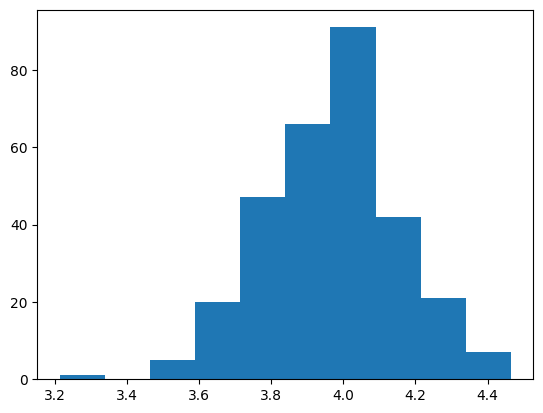

In [103]:
plt.hist(hexaco_trait_persona_df.mean(axis = 1))

<Axes: >

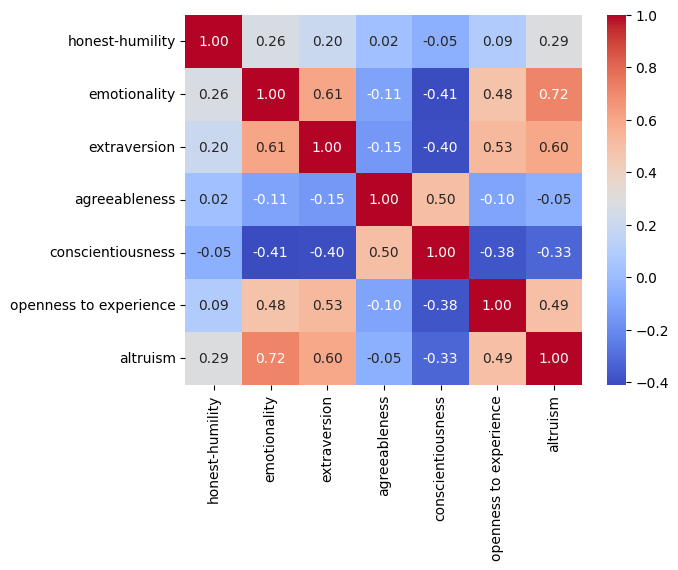

In [100]:
sns.heatmap(np.corrcoef(hexaco_trait_persona_df.T - 3),annot=True, cmap="coolwarm", fmt=".2f", cbar=True,xticklabels=hexaco_trait_persona_df.columns,yticklabels=hexaco_trait_persona_df.columns)

### TO DO: 
- for every trait, look at the mean value and std on the global data
- for every cluster, 
    - get the distribution of hexaco traits for that cluster
    - mean score of each trait
- for each archetype, 
    - look at its distribution across traits
    - look at the mean value and std

- Repeat every part of analysis for SJTs (Potential Hypothesis)
- What kind of score can be created for personas (think)
- Repeat hexaco persona experiment for different models (create a script which takes model name as input) - save plots in a folder
- for every persona, calculate avg trait score on hexaco and SJT, and get the difference


### Hypothesis
- LLM tends to agree much more than disagree when answering hexaco questions